In [1]:
library(tidyverse)
library(ggrepel)
library(ggrastr)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
all_files <- list.files("nebula_output_dir/")
rds_files <- all_files[grep("\\.rds$", all_files)]
cell_types <- sub("\\.rds$", "", rds_files)

cell_types

num_cell_types <- length(cell_types)
print(num_cell_types)

[1] "Adipocyte"     "Cardiomyocyte" "Endocardial"   "Endothelial"  
 [5] "Epicardial"    "Fibroblast"    "LEC"           "Lymphoid"     
 [9] "Mast"          "Myeloid"       "Neuronal"      "Pericyte"     
[13] "vSMC"

[1] 13


In [3]:
plots_dir <- "NEBULA_plots/"
dir.create(plots_dir)

Warning message in dir.create(plots_dir):
“'NEBULA_plots' already exists”


In [4]:
results_dir <- "NEBULA_results/"
dir.create(results_dir)

Warning message in dir.create(results_dir):
“'NEBULA_results' already exists”


In [11]:
plot_volcano <- function(markers_df, number_of_marker_genes,
                         title, logfc_threshold = 0.1, pval_threshold = 0.05, contrast) {

    # remove NA values
    markers_df <- na.omit(markers_df)

    # FC and p-value column name 
    fc_col <- paste0("logFC_", contrast)
    pval_col <- paste0("p_adj_", contrast) 
    
    # add a tiny amount to the p-values since log10(0) will not show up
    markers_df[[pval_col]] <- markers_df[[pval_col]] + 1e-300
    neg_log_10_p_val_threshold <- -1 * log10(pval_threshold)

    # identify the significant genes
    markers_df$status <- "non-significant"
    markers_df[which(markers_df[[fc_col]] > logfc_threshold & markers_df[[pval_col]] < pval_threshold), "status"] <- "up"
    markers_df[which(markers_df[[fc_col]] < -1 * logfc_threshold & markers_df[[pval_col]] < pval_threshold), "status"] <- "down"

    # number of up and downregulated
    num_up_genes <- dim(dplyr::filter(markers_df, status == "up"))[1]
    num_down_genes <- dim(dplyr::filter(markers_df, status == "down"))[1]
    
    # display the top genes that are significant
    significant_genes_df = dplyr::filter(markers_df, status %in% c("up", "down"))
    top_genes <- head(significant_genes_df[order(significant_genes_df[[pval_col]]), ], number_of_marker_genes)

    # display volcano plot using aes_string for dynamic column names
    volcano_plot <- ggplot(markers_df, aes_string(x = fc_col, y = paste0("-log10(", pval_col, ")"))) +
    geom_point_rast(aes(color = status), alpha = 0.8) +
    geom_text_repel(data = top_genes, aes(label = gene), size = 5) +
    geom_vline(xintercept = logfc_threshold, linetype = "dashed", color = "gray") +
    geom_vline(xintercept = -1 * logfc_threshold, linetype = "dashed", color = "gray") +
    geom_hline(yintercept = neg_log_10_p_val_threshold, linetype = "dashed", color = "gray") +
    scale_color_manual(values = c("non-significant" = "gray", 
                                "up" = "red",
                                "down" = "blue")) +
    labs(title = title, x = expression(log[2]~"(fold change)"), y = expression(-log[10]~"(adjusted p-value)")) +
    annotate("text", x = max(markers_df[[fc_col]]), y = max(-log10(markers_df[[pval_col]])) * 1.1,
           label = paste("Upregulated:", num_up_genes), hjust = 1, size = 6) +
    annotate("text", x = min(markers_df[[fc_col]]), y = max(-log10(markers_df[[pval_col]])) * 1.1, 
           label = paste("Downregulated:", num_down_genes), hjust = 0, size = 6) +
    ylim(0, max(-log10(markers_df[[pval_col]])) * 1.1) + 
    theme_minimal() + 
    theme(
      plot.title = element_text(size = 24, hjust = 0.5), 
      axis.text.x = element_text(angle = 0, hjust = 1, size = 16),
      axis.text.y = element_text(size = 16), 
      axis.title.x = element_text(size = 18),
      axis.title.y = element_text(size = 18),
      legend.text = element_text(size = 16), 
      legend.title = element_text(size = 18),
        legend.position = "none"
    )

    return(volcano_plot)
}

In [12]:
count_DE_genes <- function(DE_res, FC_threshold, p_adj_threshold, contrast) {

    "Count the number of DE genes for a specific contrast and specified FC and padj threshold"

    fc_col <- sym(paste0("logFC_", contrast))
    pval_col <- sym(paste0("p_adj_", contrast))

    DE_res_sig <- DE_res %>% filter( {{pval_col}} <= p_adj_threshold)
    DE_res_up <- DE_res_sig %>% filter( {{fc_col}} >= FC_threshold)
    DE_res_down <- DE_res_sig %>% filter( {{fc_col}} <= - 1 * FC_threshold) 
    
    num_up_genes <- dim(DE_res_up)[1]
    num_down_genes <- dim(DE_res_down)[1]

    num_DE <- c(num_up_genes, num_down_genes)
    
    return(num_DE)
}

In [13]:
cell_type <- "Adipocyte"
DE_fits <- readRDS(paste0("nebula_output_dir/", cell_type, ".rds"))
DE_res <- DE_fits$summary

convergent_indices <- DE_fits$convergence >= -10
filt_DE_res <- DE_res[convergent_indices, ]

# perform the BH correction
filt_DE_res$p_adj_age <- p.adjust(filt_DE_res$p_age_groupold)
filt_DE_res$p_adj_sexmale <- p.adjust(filt_DE_res$p_sexmale)

In [14]:
colnames(DE_res)

[1] "logFC_(Intercept)"                                  
 [2] "logFC_sexmale"                                      
 [3] "logFC_age_groupmiddle"                              
 [4] "logFC_age_groupold"                                 
 [5] "logFC_tech_plus_study3prime-v3_Chaffin 2022"        
 [6] "logFC_tech_plus_study3prime-v3_Hill 2022"           
 [7] "logFC_tech_plus_study3prime-v3_Kuppe 2022"          
 [8] "logFC_tech_plus_study3prime-v3_Litvinukova 2020"    
 [9] "logFC_tech_plus_study3prime-v3_Reichart 2022"       
[10] "logFC_tech_plus_study3prime-v3_Simonson 2023"       
[11] "logFC_tech_plus_study5prime-v1_Koenig 2022"         
[12] "logFC_tech_plus_studyDropseq_Penn"                  
[13] "logFC_tech_plus_studyMultiome-v1_ENCODE v4 (Snyder)"
[14] "logFC_tech_plus_studyMultiome-v1_Kanemaru 2023"     
[15] "se_(Intercept)"                                     
[16] "se_sexmale"                                         
[17] "se_age_groupmiddle"                                 
[18] "se_age_groupold"                                    
[19] "se_tech_plus_study3prime-v3_Chaffin 2022"           
[20] "se_tech_plus_study3prime-v3_Hill 2022"              
[21] "se_tech_plus_study3prime-v3_Kuppe 2022"             
[22] "se_tech_plus_study3prime-v3_Litvinukova 2020"       
[23] "se_tech_plus_study3prime-v3_Reichart 2022"          
[24] "se_tech_plus_study3prime-v3_Simonson 2023"          
[25] "se_tech_plus_study5prime-v1_Koenig 2022"            
[26] "se_tech_plus_studyDropseq_Penn"                     
[27] "se_tech_plus_studyMultiome-v1_ENCODE v4 (Snyder)"   
[28] "se_tech_plus_studyMultiome-v1_Kanemaru 2023"        
[29] "p_(Intercept)"                                      
[30] "p_sexmale"                                          
[31] "p_age_groupmiddle"                                  
[32] "p_age_groupold"                                     
[33] "p_tech_plus_study3prime-v3_Chaffin 2022"            
[34] "p_tech_plus_study3prime-v3_Hill 2022"               
[35] "p_tech_plus_study3prime-v3_Kuppe 2022"              
[36] "p_tech_plus_study3prime-v3_Litvinukova 2020"        
[37] "p_tech_plus_study3prime-v3_Reichart 2022"           
[38] "p_tech_plus_study3prime-v3_Simonson 2023"           
[39] "p_tech_plus_study5prime-v1_Koenig 2022"             
[40] "p_tech_plus_studyDropseq_Penn"                      
[41] "p_tech_plus_studyMultiome-v1_ENCODE v4 (Snyder)"    
[42] "p_tech_plus_studyMultiome-v1_Kanemaru 2023"         
[43] "gene_id"                                            
[44] "gene"

[1] "Adipocyte"


Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”


[1] 2 2


Warning message:
“Removed 12 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”
Warning message:
“Removed 12 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”


[1] 9 2
[1] "Cardiomyocyte"


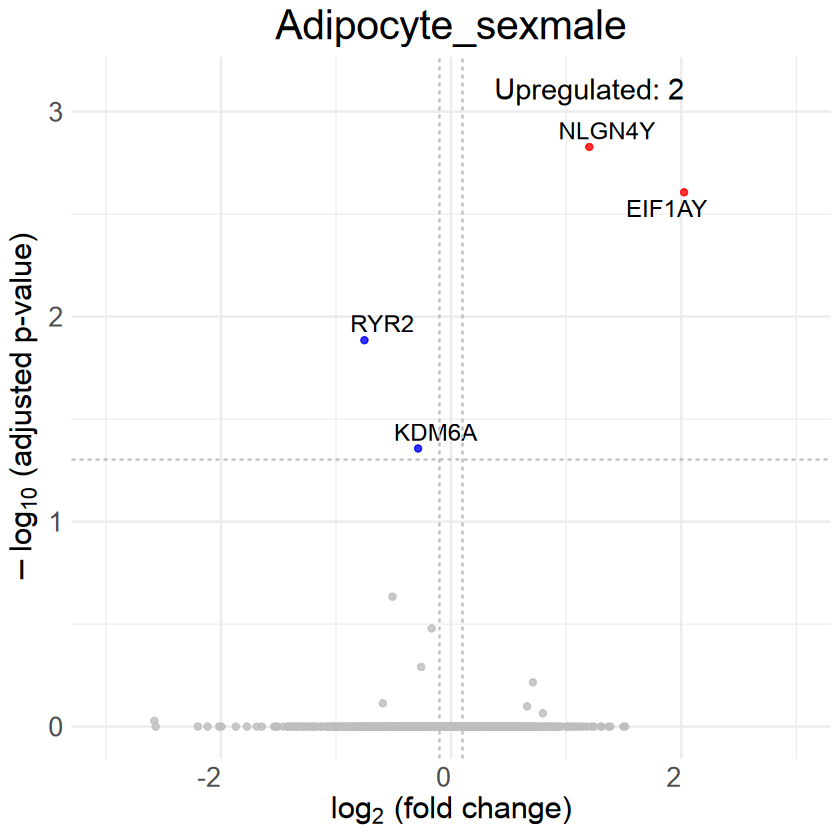

Warning message:
“ggrepel: 88 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 87 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] 114  72


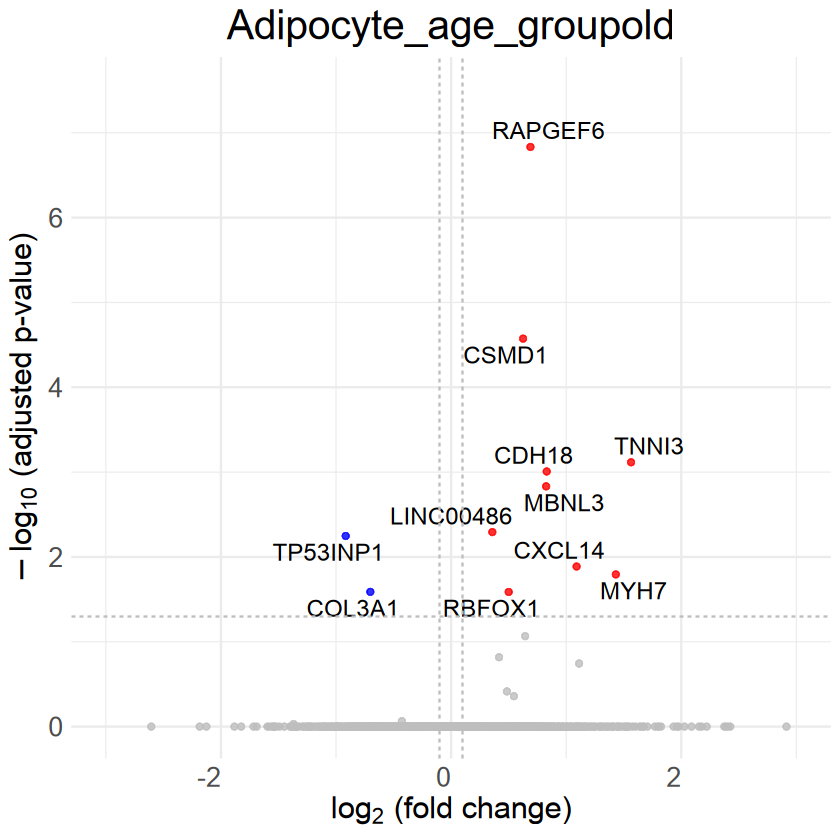

Warning message:
“ggrepel: 86 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 84 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] 114 174
[1] "Endocardial"


Warning message:
“ggrepel: 88 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


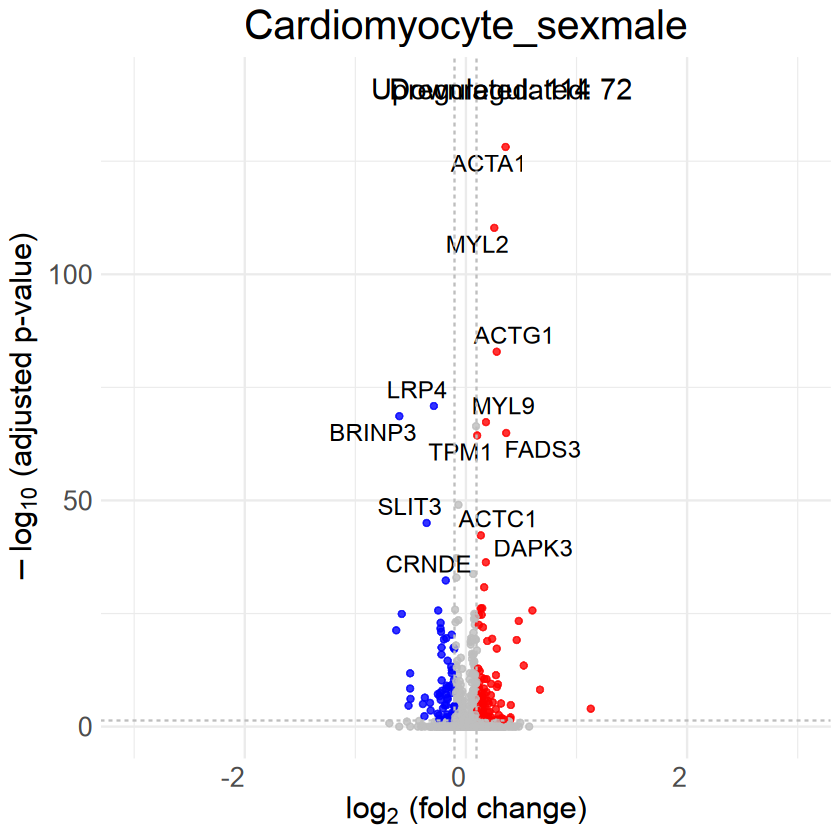

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text_repel()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text_repel()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”


[1] 7 8


Warning message:
“ggrepel: 86 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


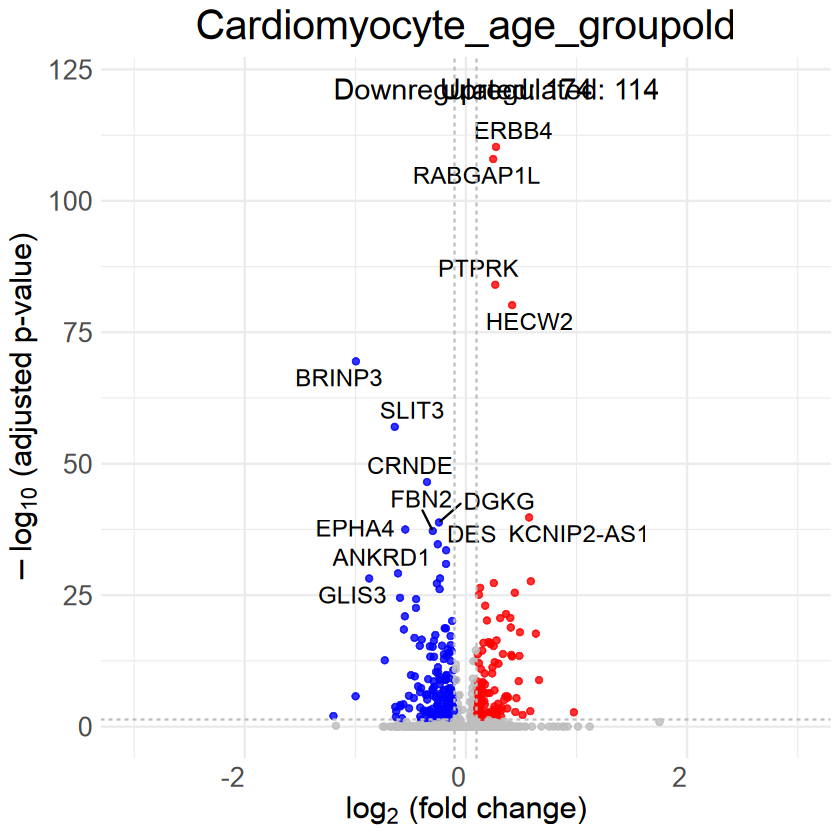

[1] 0 1
[1] "Endothelial"


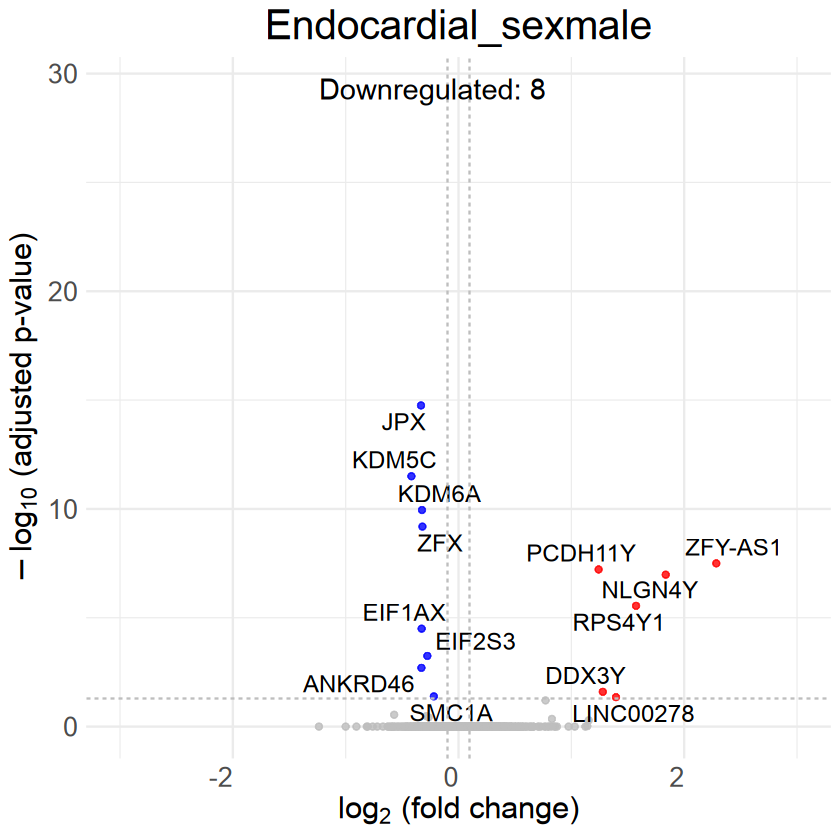

[1] 10 11


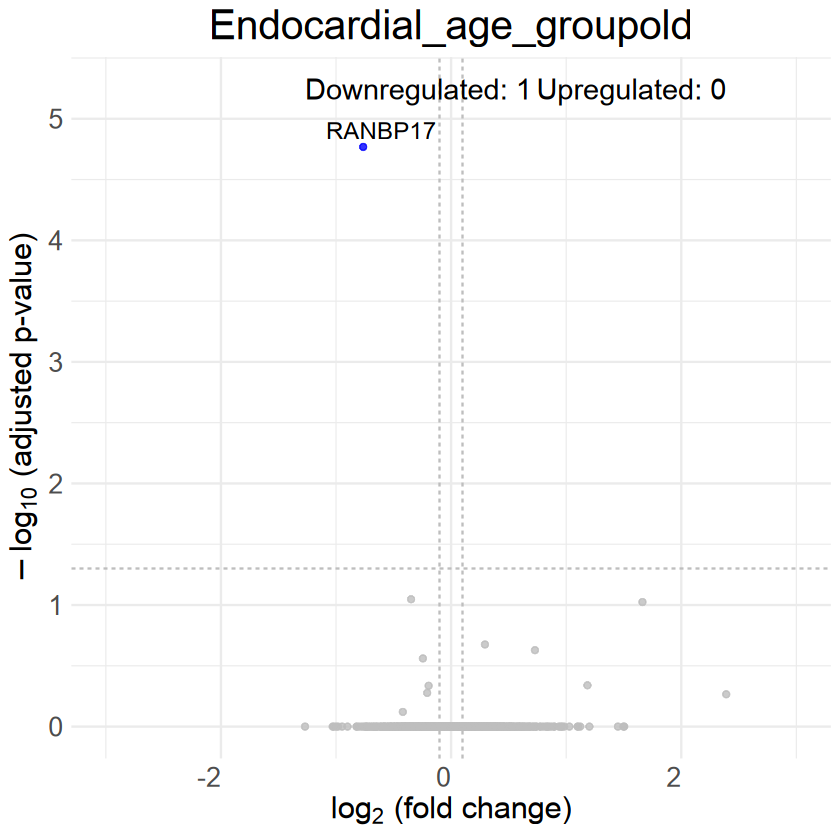

Warning message:
“ggrepel: 9 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 9 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1]  2 17
[1] "Epicardial"


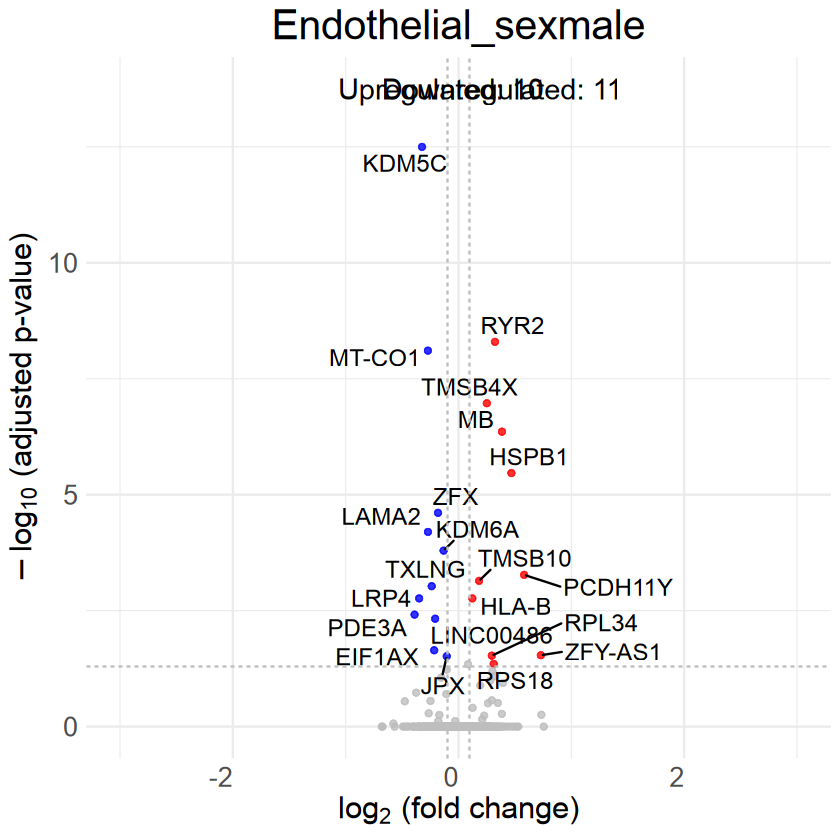

Warning message:
“Removed 9 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 9 rows containing missing values or values outside the scale range (`geom_text_repel()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”
Warning message:
“ggrepel: 18 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“Removed 9 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 9 rows containing missing values or values outside the scale range (`geom_text_repel()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()

[1] 17 20


Warning message:
“ggrepel: 9 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


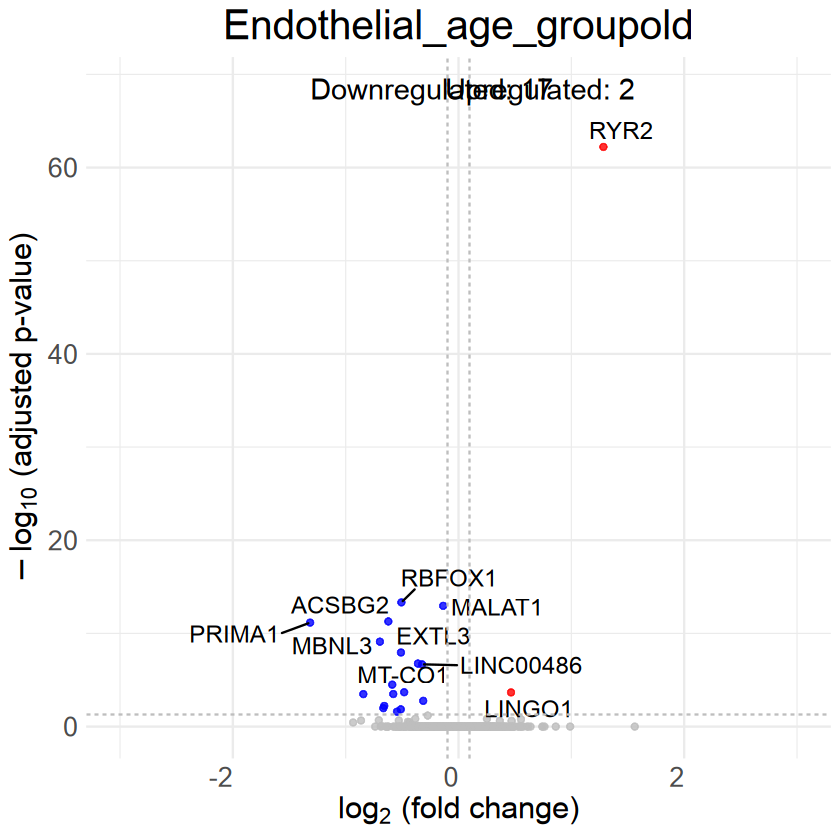

Warning message:
“Removed 307 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”
Warning message:
“Removed 307 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”


[1]  1 10
[1] "Fibroblast"


Warning message:
“ggrepel: 18 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


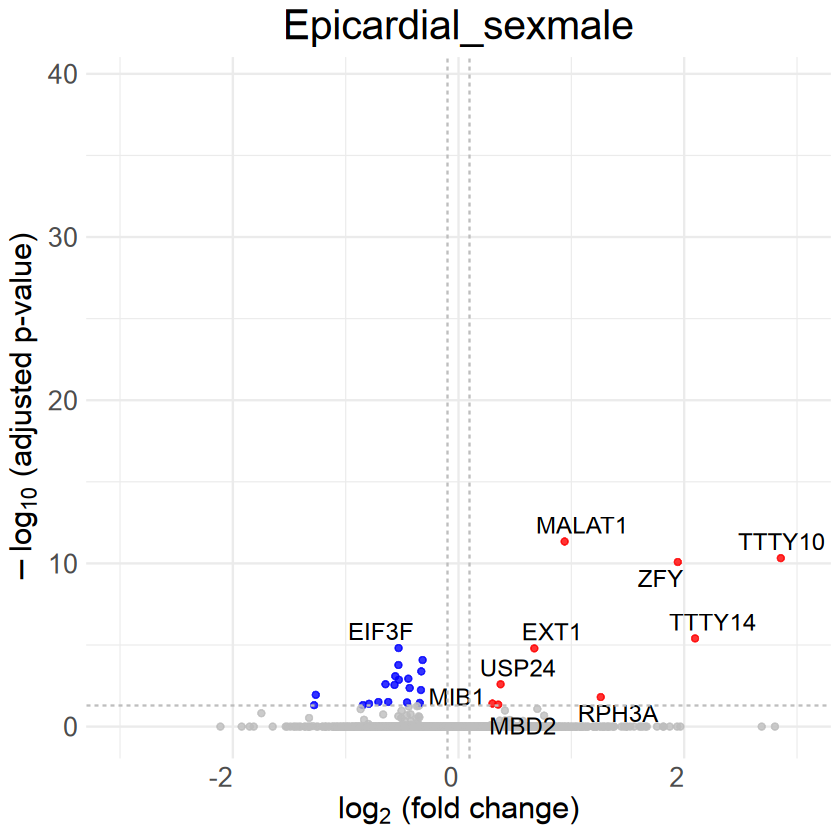

Warning message:
“ggrepel: 80 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 80 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] 33 53


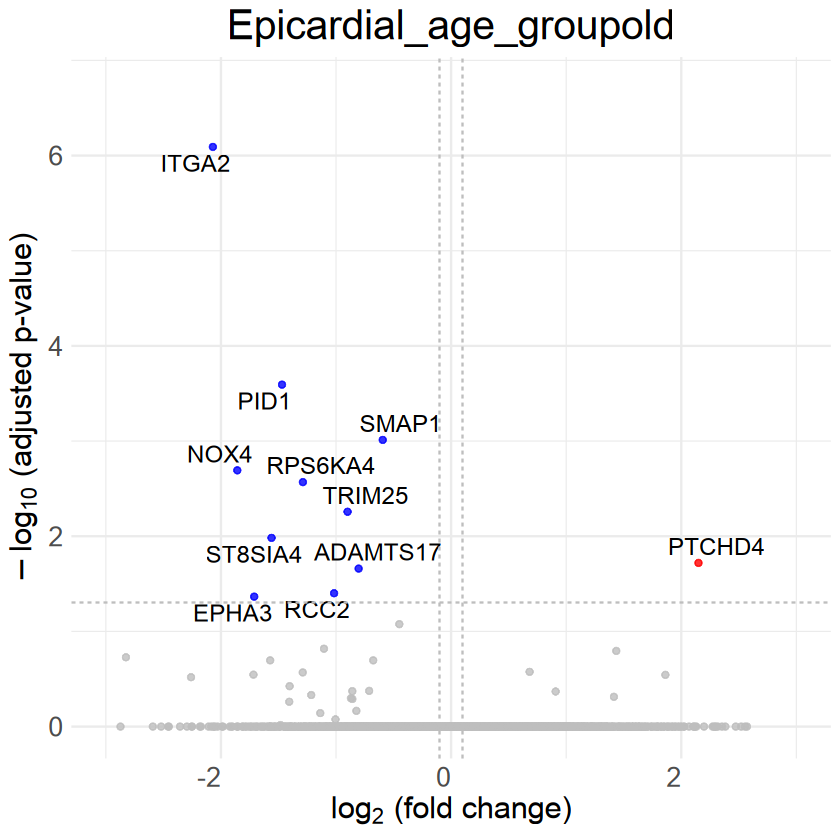

Warning message:
“ggrepel: 92 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 91 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] 82 18
[1] "LEC"


Warning message:
“ggrepel: 80 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


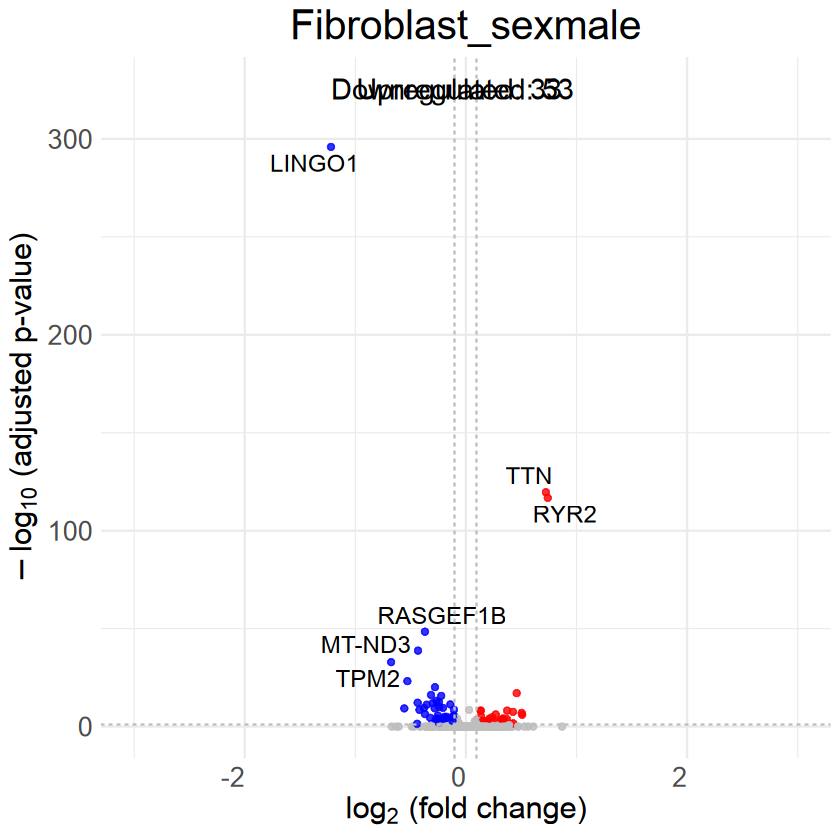

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text_repel()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text_repel()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”


[1] 11  1


Warning message:
“ggrepel: 92 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


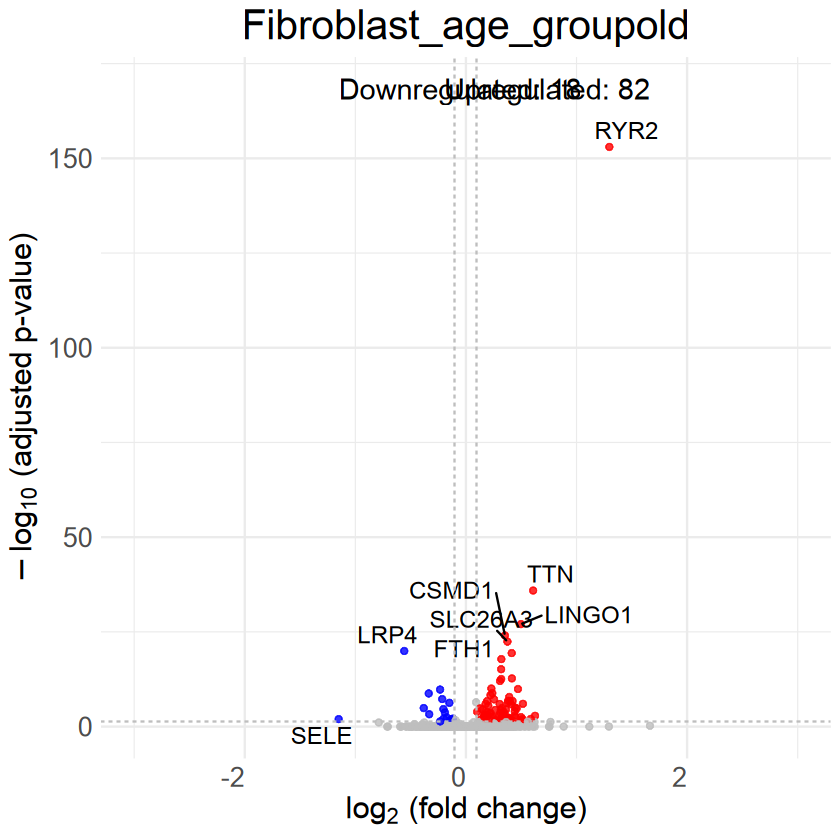

Warning message:
“Removed 7 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”
Warning message:
“Removed 7 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”


[1] 1 1
[1] "Lymphoid"


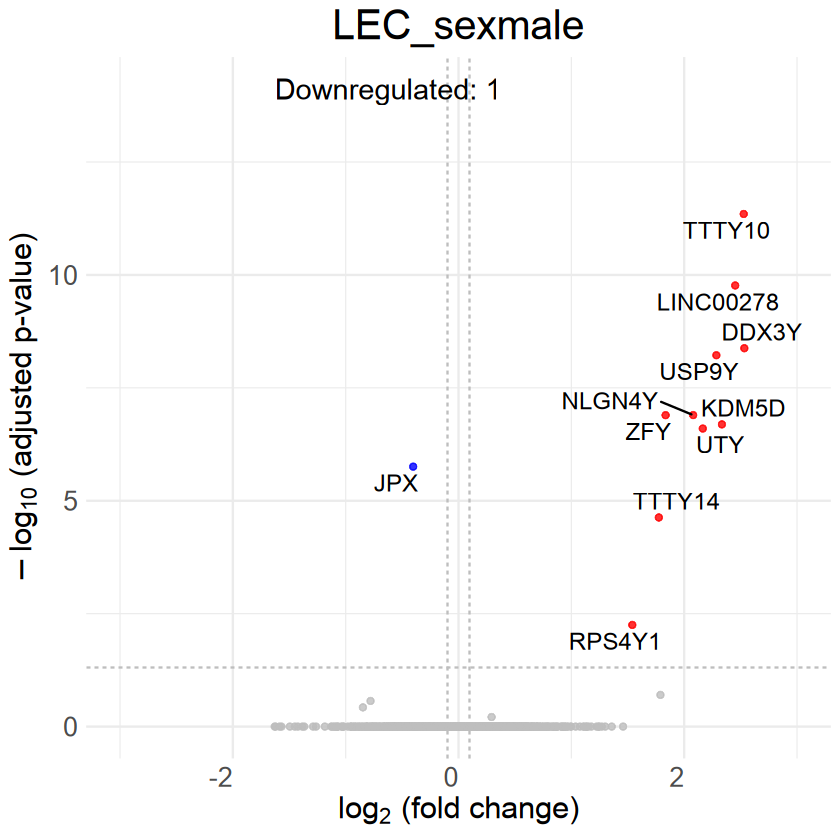

[1]  9 14


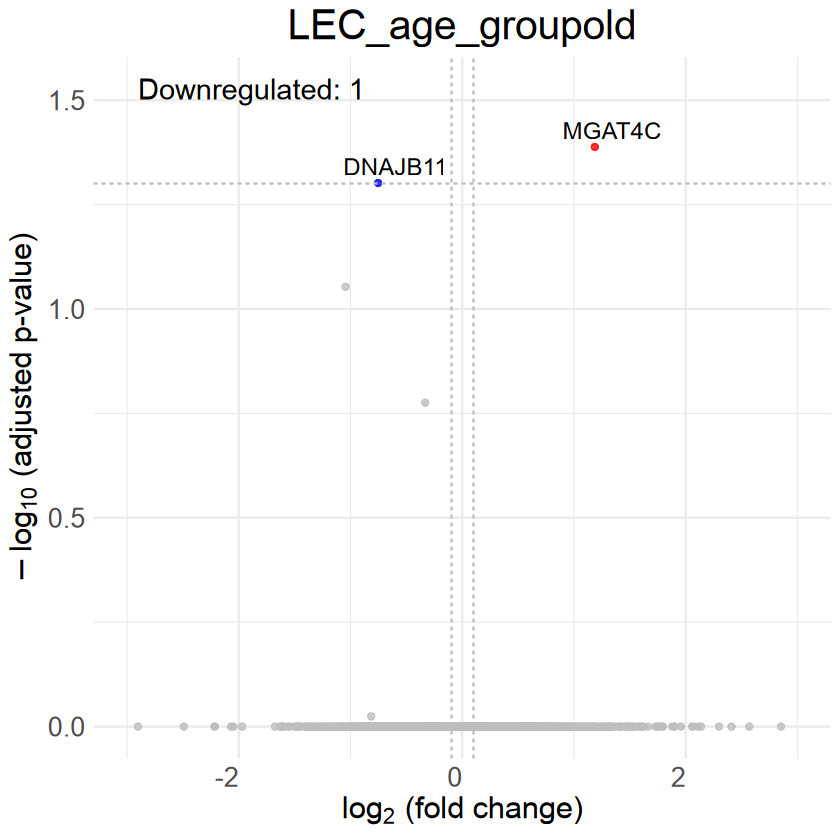

[1] 6 3
[1] "Mast"


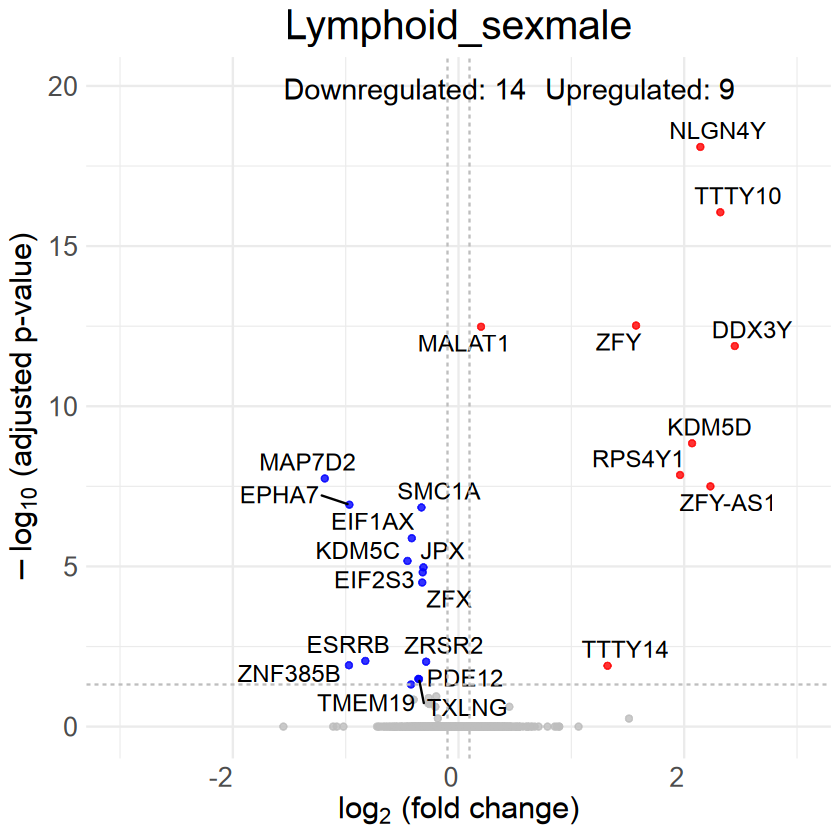

Warning message:
“Removed 3 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text_repel()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text_repel()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”


[1] 9 2


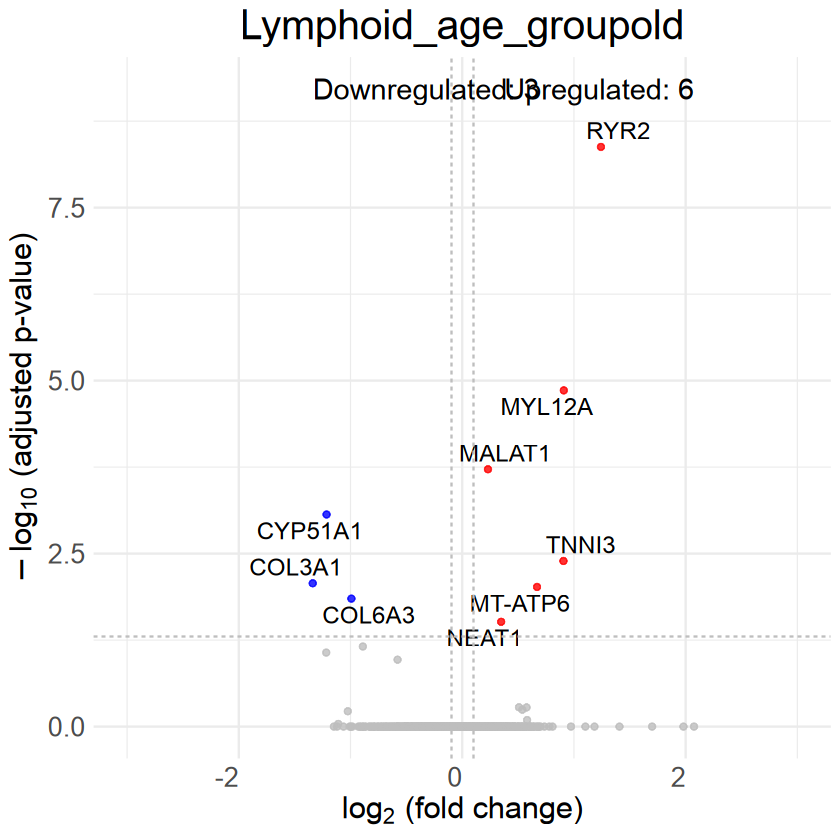

Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”


[1] 0 0
[1] "Myeloid"


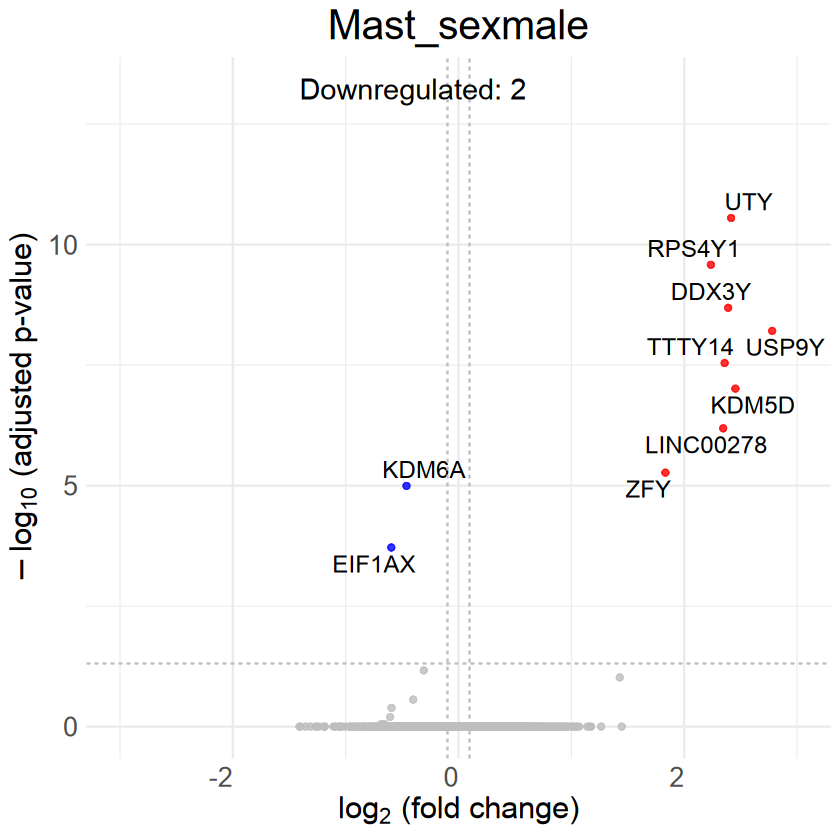

Warning message:
“ggrepel: 17 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 13 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] 19  6


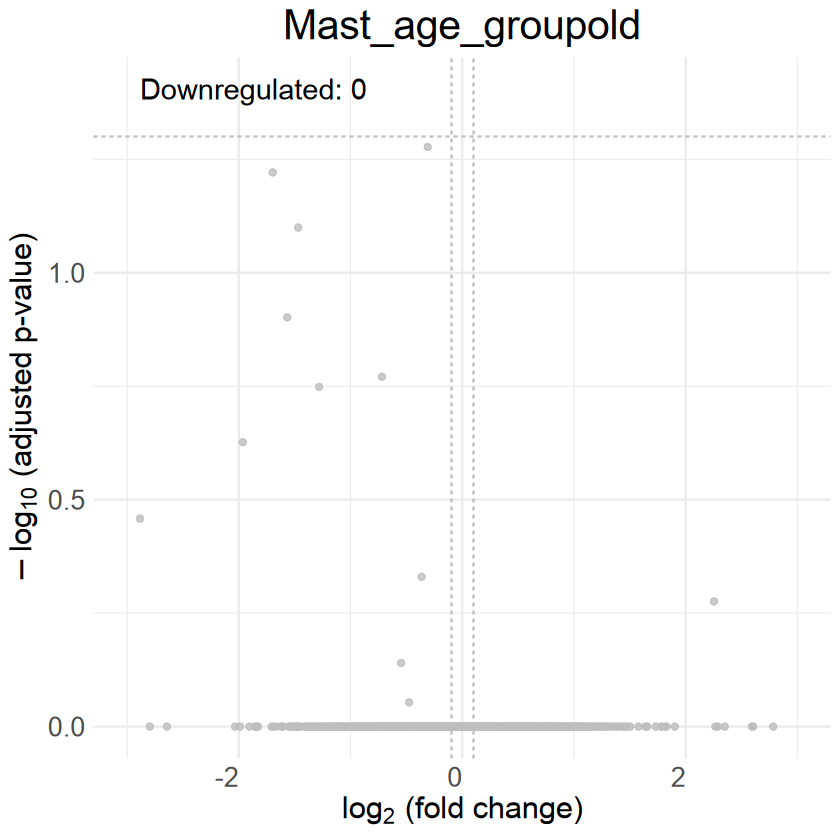

[1] 6 4
[1] "Neuronal"


Warning message:
“ggrepel: 17 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


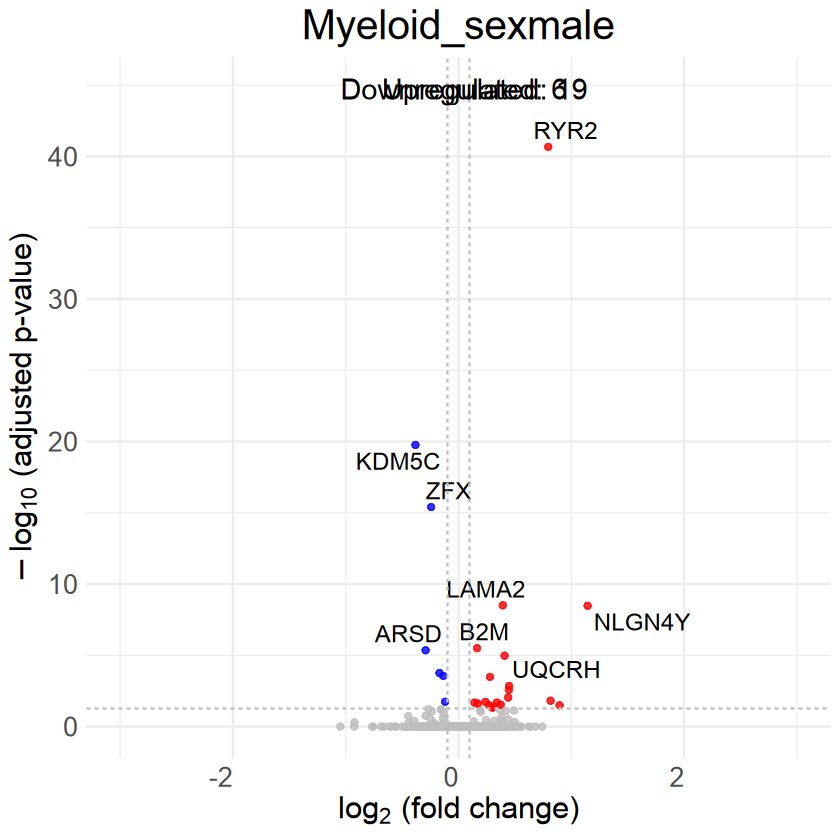

[1] 10  9


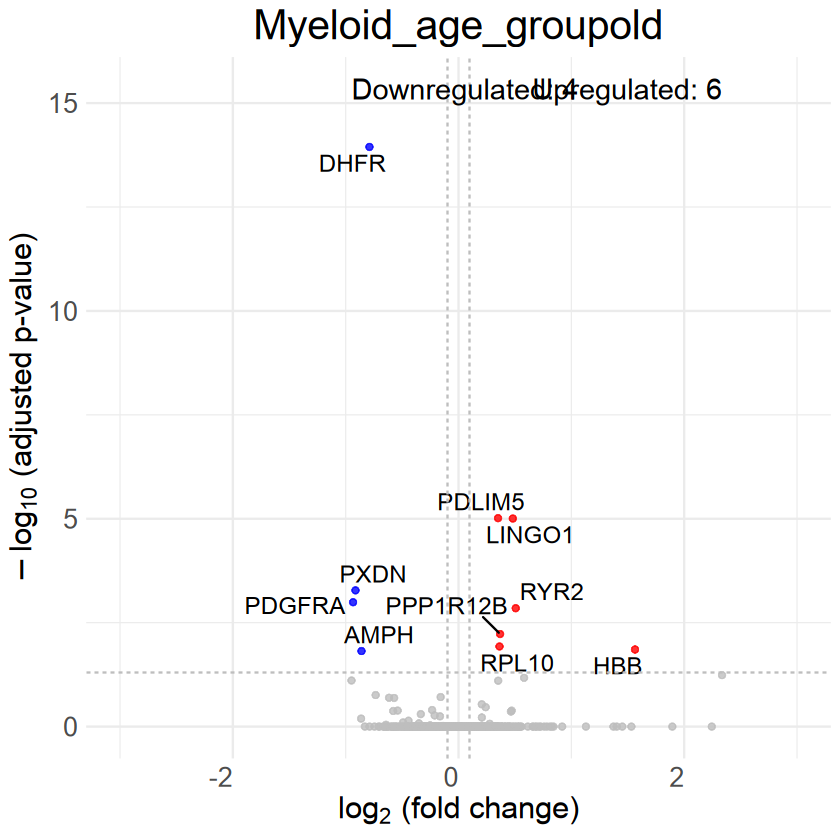

[1] 0 4
[1] "Pericyte"


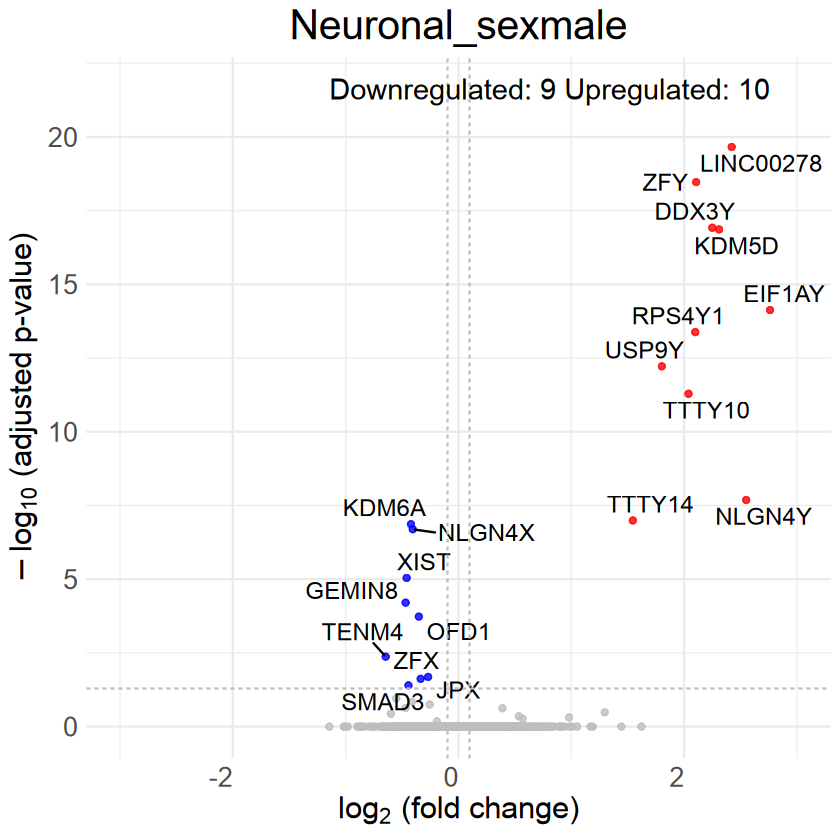

Warning message:
“ggrepel: 34 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 32 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] 36 14


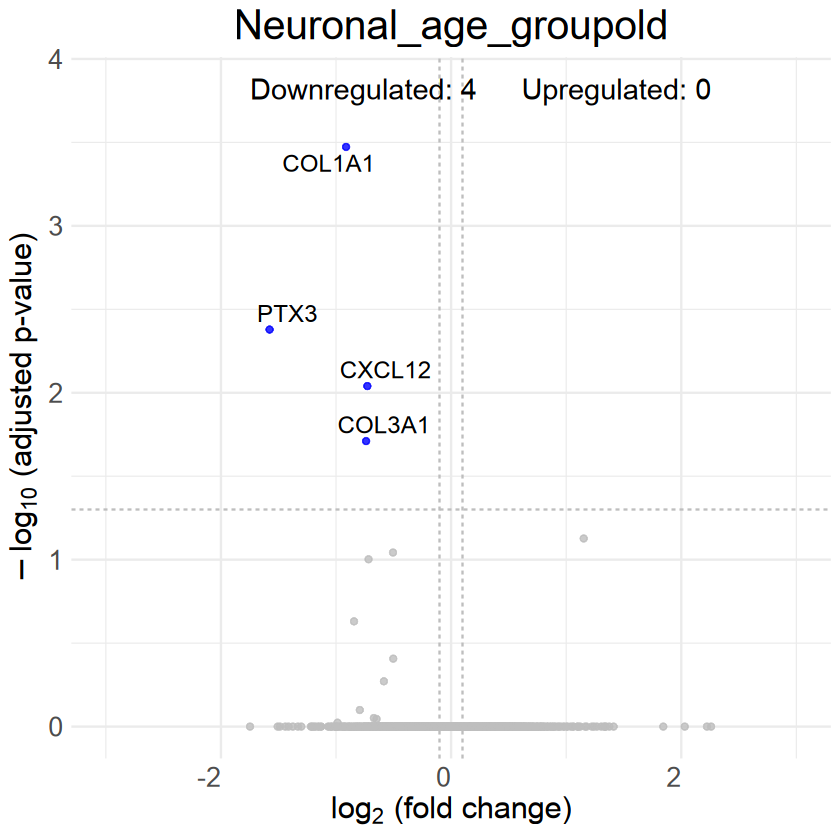

Warning message:
“ggrepel: 11 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 10 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] 14  7
[1] "vSMC"


Warning message:
“ggrepel: 34 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


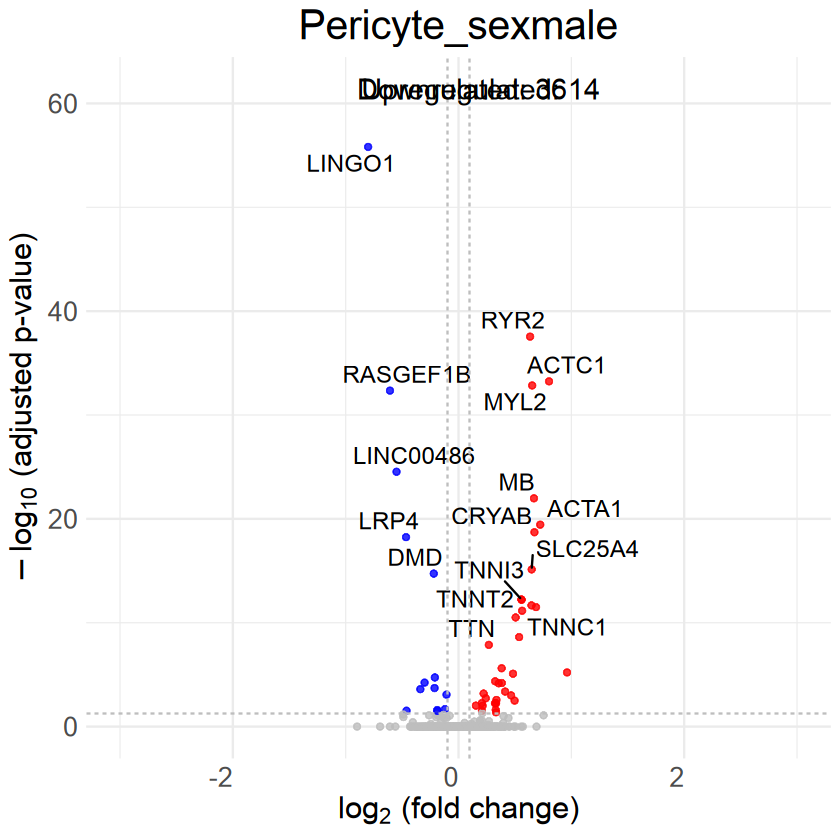

[1] 5 4


Warning message:
“ggrepel: 11 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


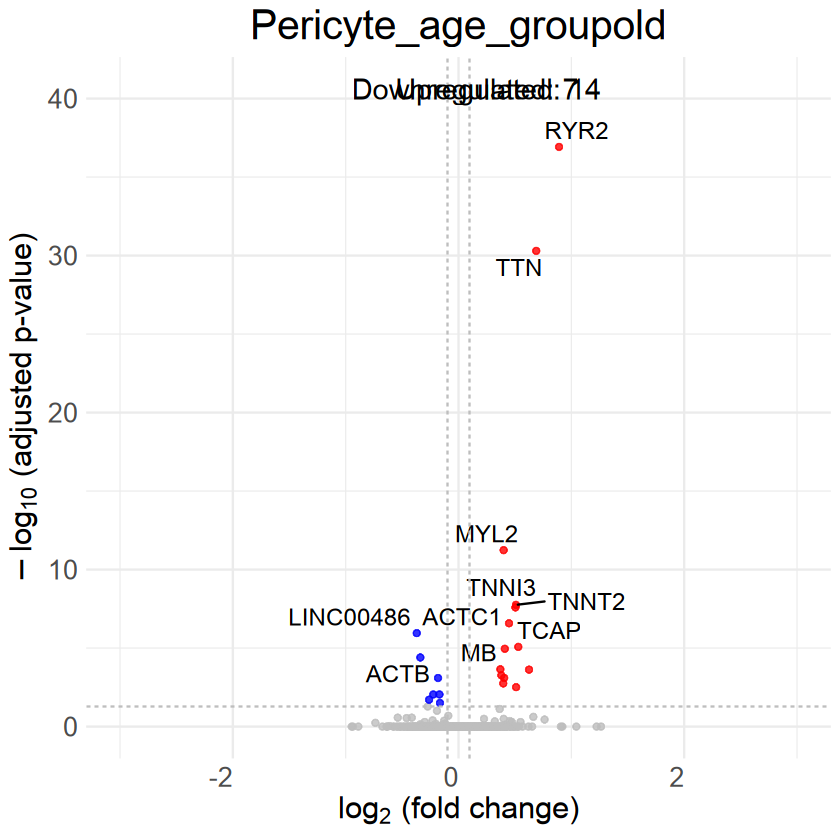

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_hline()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_hline()`).”


[1] 0 0


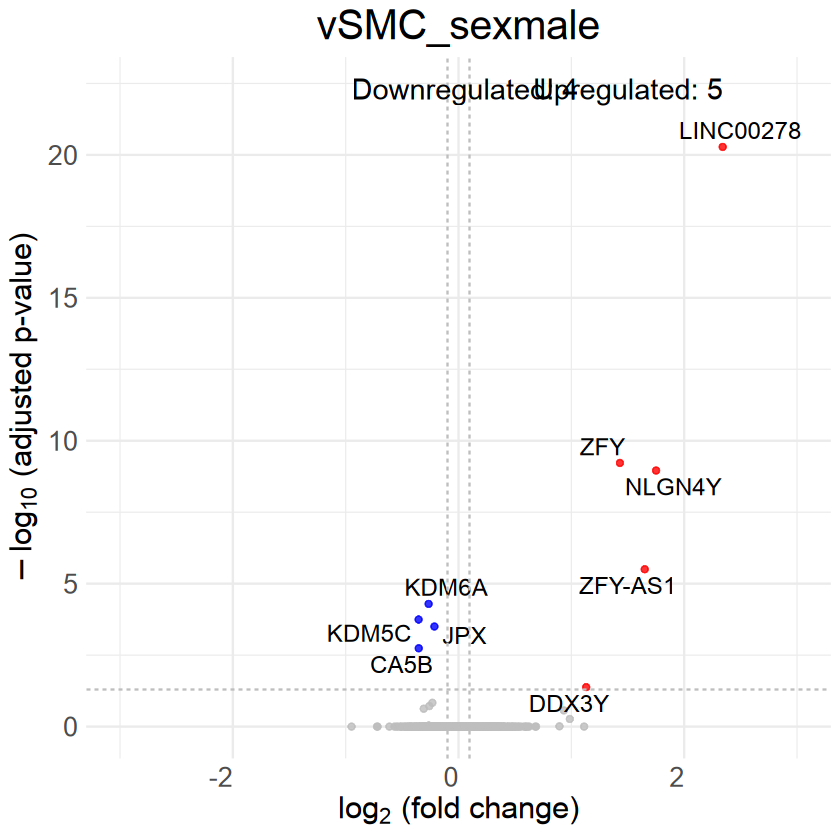

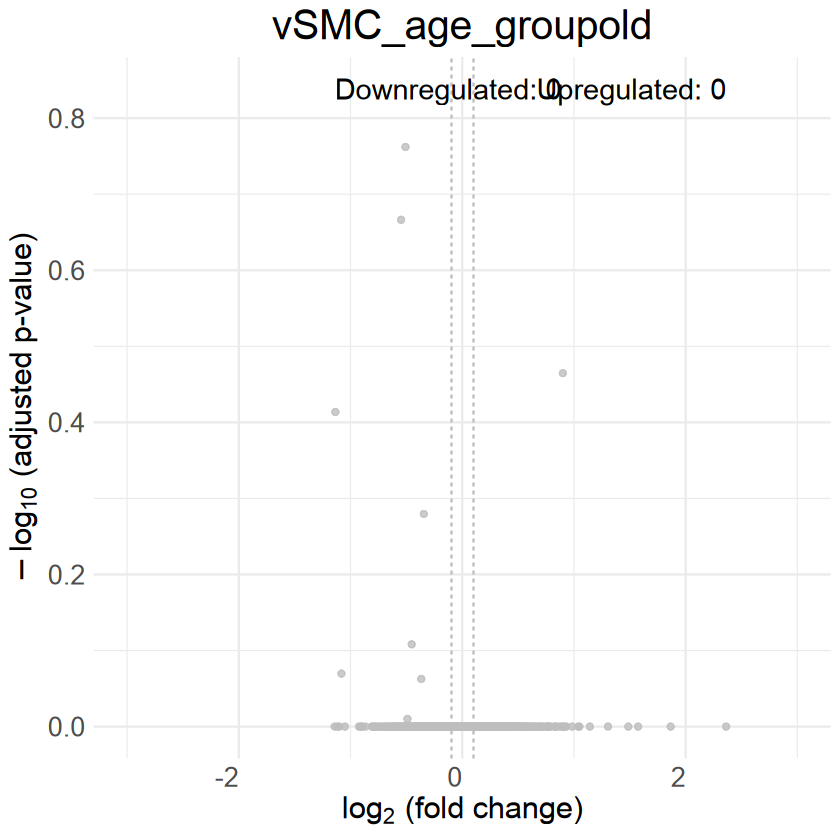

In [16]:
DE_age_up_list <- rep(0, num_cell_types)
DE_age_down_list <- rep(0, num_cell_types)
DE_sex_up_list <- rep(0, num_cell_types)
DE_sex_down_list <- rep(0, num_cell_types)

contrasts <- c("sexmale", "age_groupold")
p_val_thresh = 0.05
threshold = 1e-300

for (i in 1:num_cell_types) {

    cell_type <- cell_types[i]

    print(cell_type)
    flush.console()

    # load the in NEBULA results
    DE_fits <- readRDS(paste0("nebula_output_dir/", cell_type, ".rds"))
    # extract the df 
    DE_res <- DE_fits$summary
    
    # remove genes that did not converge well
    convergent_indices <- DE_fits$convergence >= -10
    filt_DE_res <- DE_res[convergent_indices, ]

    # perform the BH correction
    filt_DE_res$p_adj_age_groupold <- p.adjust(filt_DE_res$p_age_groupold+threshold)
    filt_DE_res$p_adj_sexmale <- p.adjust(filt_DE_res$p_sexmale+threshold)

    # save this as a csv
    write.csv(filt_DE_res, file = paste0(results_dir, cell_type, ".csv"))

    # iterate through contrasts, produce volcano plot
    for (contrast in contrasts) {
        p1 <- plot_volcano(filt_DE_res, number_of_marker_genes = 100, 
                           title = paste0(cell_type, "_", contrast), 
                           contrast = contrast) + xlim(-3, 3)
        print(p1)

        ggsave(plot = p1, filename = paste0(plots_dir, cell_type, contrast, "_volcano_plot.pdf"), height = 8, width = 7)
        
        if (contrast == "sexmale") {
            FC_thresh = 0.1
            
            n_DE_genes <- count_DE_genes(DE_res = filt_DE_res, 
                                         FC_threshold = FC_thresh,
                                         p_adj_threshold = p_val_thresh, 
                                         contrast)

            print(n_DE_genes)
            flush.console()
            DE_sex_up_list[i] <- n_DE_genes[1]
            DE_sex_down_list[i] <- n_DE_genes[2]
        }
        
        else if (contrast == "age_groupold") {
            FC_thresh = 0.1

            n_DE_genes <- count_DE_genes(DE_res = filt_DE_res, 
                                         FC_threshold = FC_thresh,
                                         p_adj_threshold = p_val_thresh, 
                                         contrast)

            print(n_DE_genes)
            flush.console()
            
            DE_age_up_list[i] <- n_DE_genes[1]
            DE_age_down_list[i] <- n_DE_genes[2]
        }
        
    }
}

### Display the results in a plot

In [ ]:
overall_results_tibble <- tibble(`cell_type` = cell_types,
                                `age_up` = DE_age_up_list,
                                `age_down` = DE_age_down_list,
                                `sex_up` = DE_sex_up_list,
                                `sex_down` = DE_sex_down_list)
overall_results_tibble

In [ ]:
# make this tidy
age_tidy_df <- overall_results_tibble %>% select("cell_type", "age_up", "age_down") %>% pivot_longer(cols = starts_with("age_"), 
               names_to = c("condition", "direction"), 
               names_sep = "_", 
               values_to = "count")  %>%
  mutate(condition = "age")

sex_tidy_df <- overall_results_tibble %>%  select("cell_type", "sex_up", "sex_down") %>%
      pivot_longer(cols = starts_with("sex_"), 
                   names_to = c("condition", "direction"), 
                   names_sep = "_", 
                   values_to = "count") %>%
      mutate(condition = "sex")

In [ ]:
# add the bar plot values directly above the bars
barplot_with_text <- function(plot_data, condition_title) {
  ggplot(plot_data, aes(x = cell_type, y = count, fill = direction)) +
    geom_bar(stat = "identity", position = position_dodge()) +
    geom_text(aes(label = count), vjust = -0.5, position = position_dodge(width = 0.9), size = 5) +  # Adding text labels
    labs(title = condition_title, x = "cell type", y = "number of genes") +
    scale_fill_manual(values = c("up" = "blue", "down" = "red")) +
    theme_minimal() + theme(legend.text = element_text(size = 16), 
         legend.title = element_text(size = 16), 
         plot.title = element_text(size = 24, hjust = 0.5), 
         axis.title.x = element_text(size = 16),
         axis.title.y = element_text(size = 16),
         axis.text.x = element_text(size = 16),
         axis.text.y = element_text(size = 16)) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
}

### Produce barplots 

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 8) 
age_plot <- barplot_with_text(age_tidy_df, "# of aging DEGs")
ggsave(plot = age_plot, paste0(plots_dir, "Aging_DEGs.pdf"), width = 10, height = 8)
age_plot

In [ ]:
sex_plot <-  barplot_with_text(sex_tidy_df, "# of sex DEGs")
ggsave(plot = sex_plot, paste0(plots_dir, "Sex_DEGs.pdf"), width = 10, height = 8)
sex_plot